# Bernstein-Vazirani
The oracle hides a secret string $s$ via $f(x)=s\cdot x \bmod 2$. One query recovers all $n$ bits of $s$ at once.
Measure the input register: the bitstring you read out **is** $s$.
Same setup as Deutsch-Jozsa — run on the real backend and a noise-matched simulator, in parallel.

In [9]:
# Connect to IBM Quantum (account already saved earlier)
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

In [10]:
# Pick the real backend and build a Sampler bound to it
from qiskit_ibm_runtime import SamplerV2 as Sampler

backend = service.backend("ibm_marrakesh")
sampler = Sampler(mode=backend)
print(backend.name)

ibm_marrakesh


In [11]:
# Build a local Aer simulator that mimics the backend's noise
from qiskit.primitives import BackendSamplerV2
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

noise_model = NoiseModel.from_backend(backend)
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)

In [12]:
# Oracle: CX from input qubit i into the target wherever secret bit s_i = 1
from qiskit import QuantumCircuit

def bv_oracle(s: str) -> QuantumCircuit:
    n = len(s)
    oracle = QuantumCircuit(n + 1)
    for i, bit in enumerate(reversed(s)):   # qubit 0 = least-significant bit
        if bit == "1":
            oracle.cx(i, n)
    return oracle

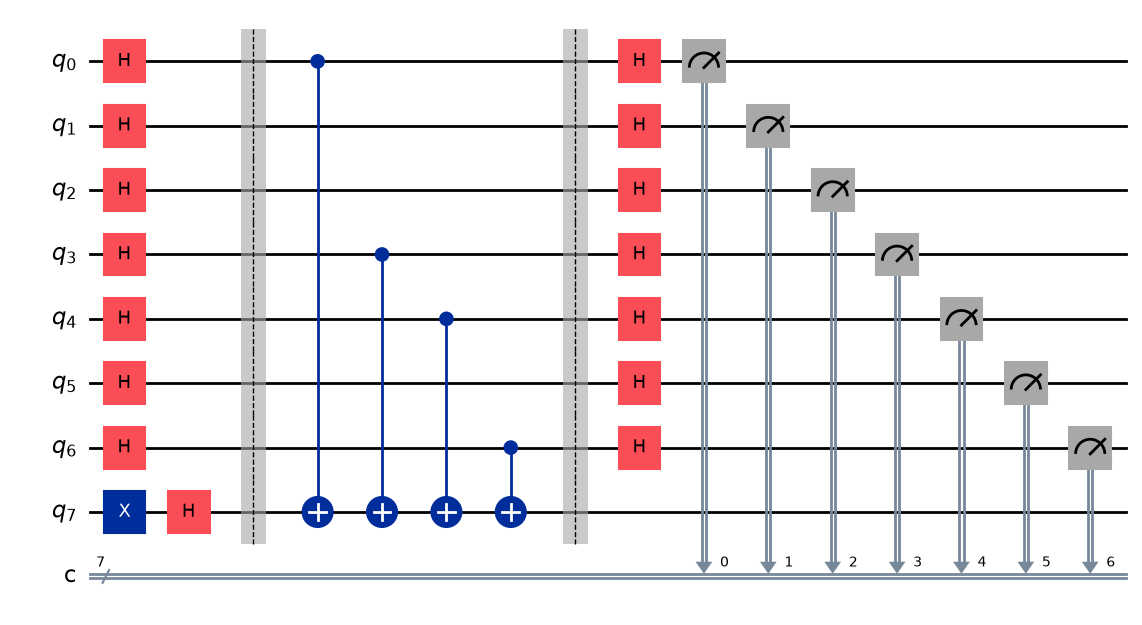

In [ ]:
# Assemble the full Bernstein-Vazirani circuit and draw it
s = "1111001"                    # the secret to recover
n = len(s)

qc = QuantumCircuit(n + 1, n)
qc.x(n)                       # target starts in |1>
qc.h(range(n + 1))            # superposition + |-> on target
qc.barrier()
qc.compose(bv_oracle(s), inplace=True)
qc.barrier()
qc.h(range(n))               # interference collapses the input register onto s
qc.measure(range(n), range(n))

qc.draw("mpl")

In [14]:
# Transpile to the backend's native gates/qubits (ISA circuit)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)
qc_isa = pm.run(qc)

In [15]:
# Submit both jobs first so they run in parallel, then collect results
job_real = sampler.run([qc_isa], shots=1024)
job_sim = sampler_sim.run([qc_isa], shots=1024)

counts_real = job_real.result()[0].data.c.get_counts()
counts_sim = job_sim.result()[0].data.c.get_counts()

secret s        : 1011001
real most freq  : 1011001
sim  most freq  : 1011001


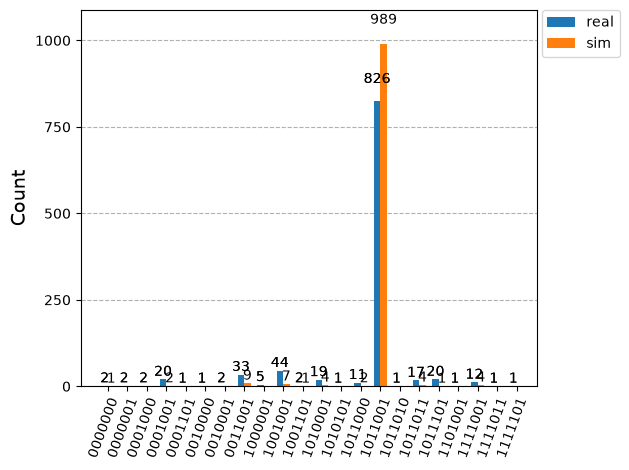

In [16]:
# Compare the two histograms; the dominant bitstring should equal s
from qiskit.visualization import plot_histogram

print("secret s        :", s)
print("real most freq  :", max(counts_real, key=counts_real.get))
print("sim  most freq  :", max(counts_sim, key=counts_sim.get))
plot_histogram([counts_real, counts_sim], legend=["real", "sim"])